In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os

from sklearn.model_selection import train_test_split


In [30]:
# Loading the datasets
categories = ['Cardboard', 'Food Organics' ,'Glass' , 'Metal', 'Miscellaneous Trash', 'Paper' , 'Plastic' ,'Textile Trash']
labels = {cat : index for index , cat in enumerate(categories)}

images_per_category=[[],[],[],[],[],[],[],[]]
images_per_category_label=[[],[],[],[],[],[],[],[]]

for index , cat in enumerate(categories):
    basefolder ="RealWaste/"
    sub_directory = os.path.join(basefolder,cat)
    sub_list = os.listdir(sub_directory)

    for image_path in sub_list:
        full_image_path =os.path.join(sub_directory,image_path)
        image_array = cv2.imread(full_image_path)
        images_per_category[index].append(image_array)
        images_per_category_label[index].append(index)



In [66]:
print('Lenght of first category (cardboard) : ',len(images_per_category[2]))
print('Lenght of first category (cardboard) : ',len(images_per_category_label[0]))

Lenght of first category (cardboard) :  420
Lenght of first category (cardboard) :  461


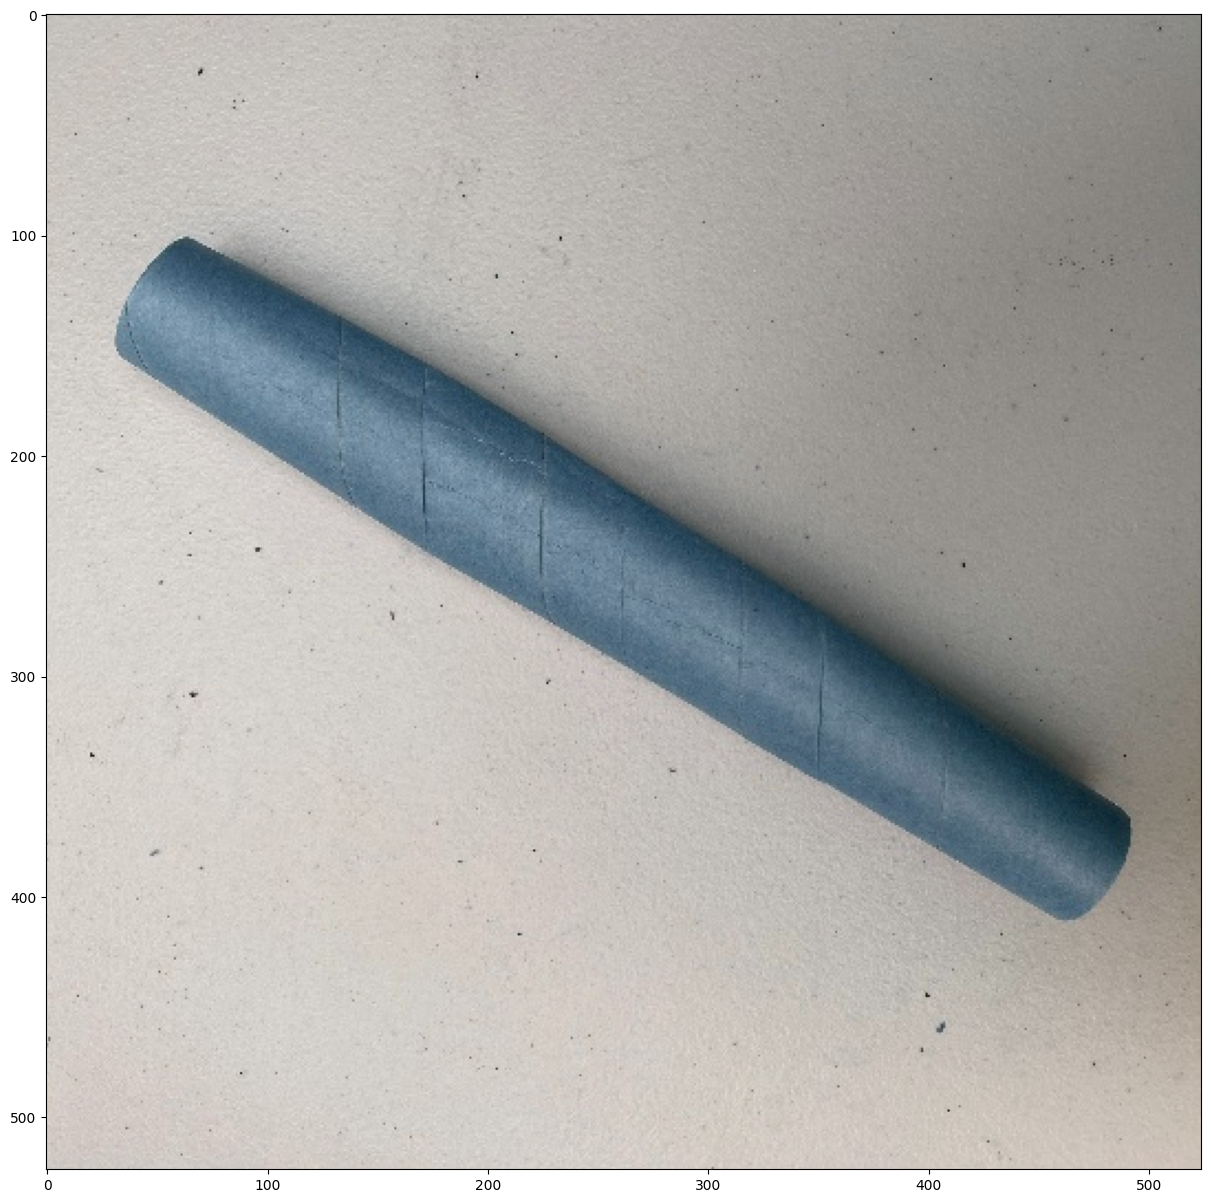

In [33]:
plt.figure(figsize=(15,15))
plt.imshow(images_per_category[0][0])

Merging the list

In [34]:
all_image=[]
all_image_label=[]
for image_set , label_set in zip(images_per_category,images_per_category_label):
    for per_image , per_label in zip(image_set,label_set):
        all_image.append(per_image)
        all_image_label.append(per_label)

print('Total Number of images : ' , len(all_image))


Total Number of images :  4316


Preprocessing the images --> Resizing

In [64]:
len(all_image[0])

256

In [36]:
target_width = 256
target_height = 256

for index , image in enumerate(all_image):
    all_image[index] = cv2.resize(image ,(target_height,target_width),interpolation=cv2.INTER_AREA)


In [37]:
len(all_image[0])

256

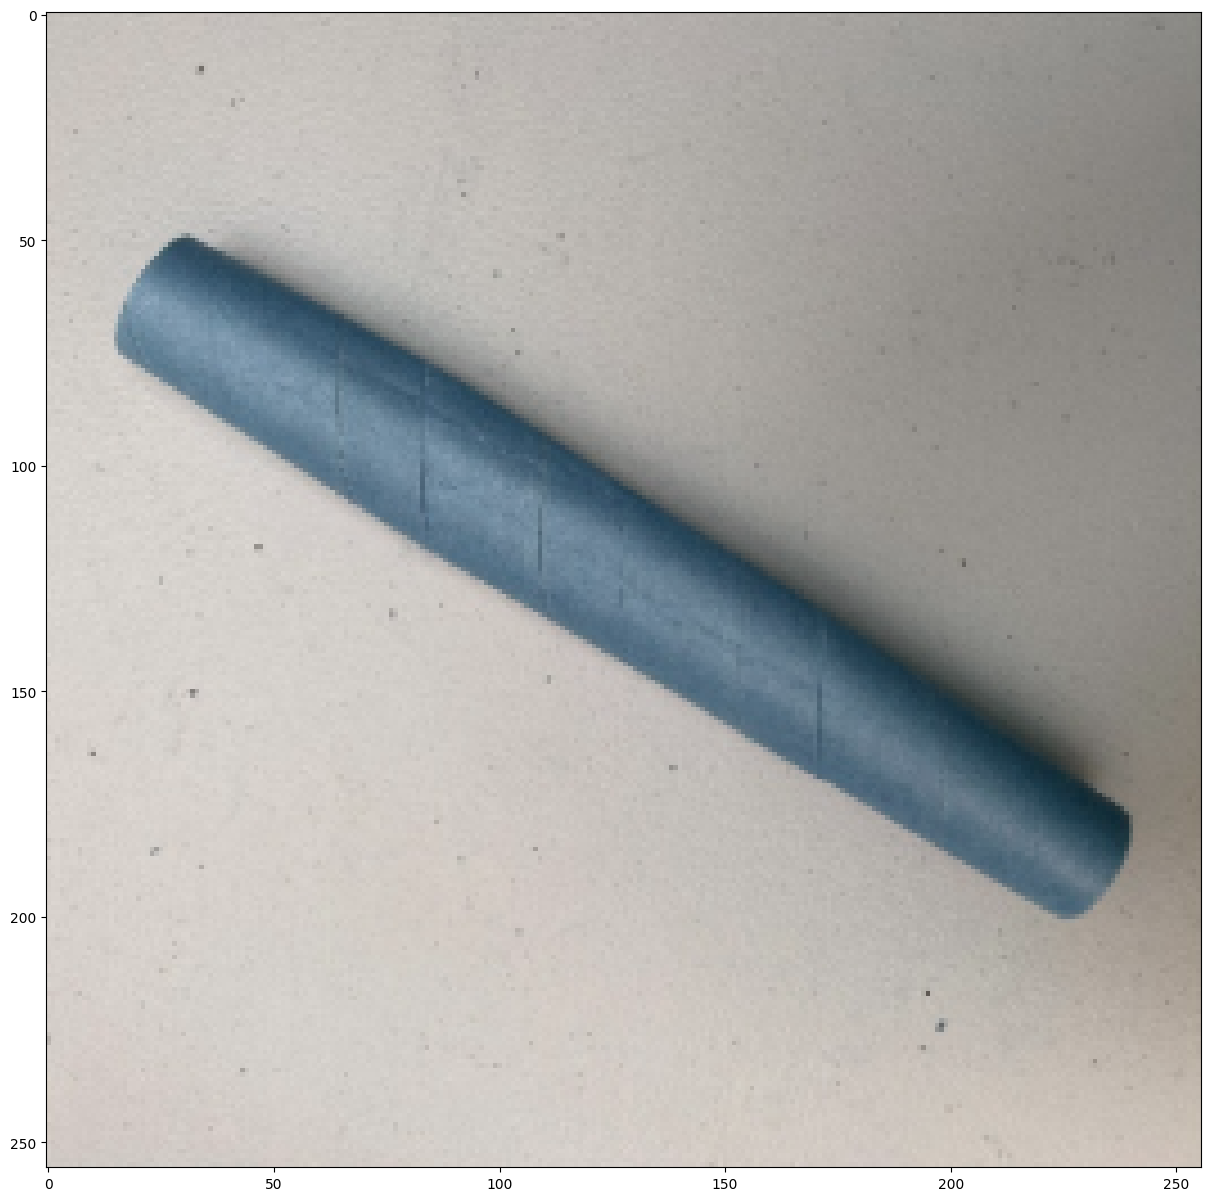

In [38]:
plt.figure(figsize=(15,15))
plt.imshow(all_image[0])

Converting the color of image from BGR ---> RGB

In [39]:
for index , image in enumerate(all_image):
    all_image[index] = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)

Reducing the Noise in Image

In [40]:
guassian_sample=[]
median_blur=[]
bilateral_filter=[]
for index , image in enumerate(all_image):
    #guassian_sample.append(cv2.GaussianBlur(image, ksize=(5,5), sigmaX=0))
    #median_blur.append(cv2.medianBlur(image,ksize=5))
    bilateral_filter.append(cv2.bilateralFilter(image ,d=7 , sigmaColor= 50,sigmaSpace=50))

Visualizing the Images

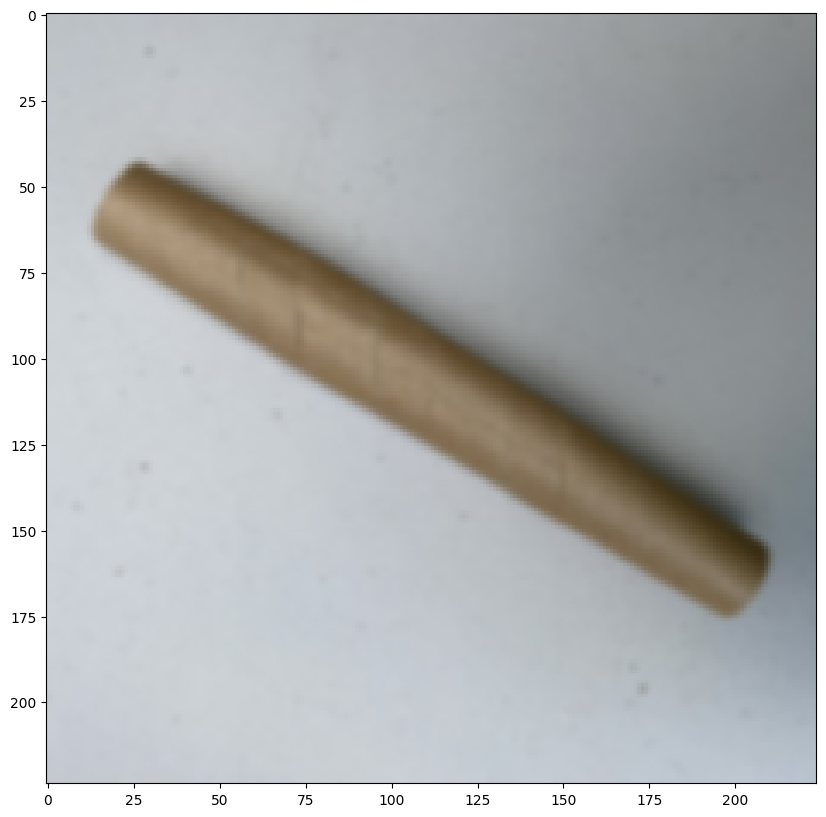

In [100]:
#Guassian blur
plt.figure(figsize=(10,10))
plt.imshow(guassian_sample[0])

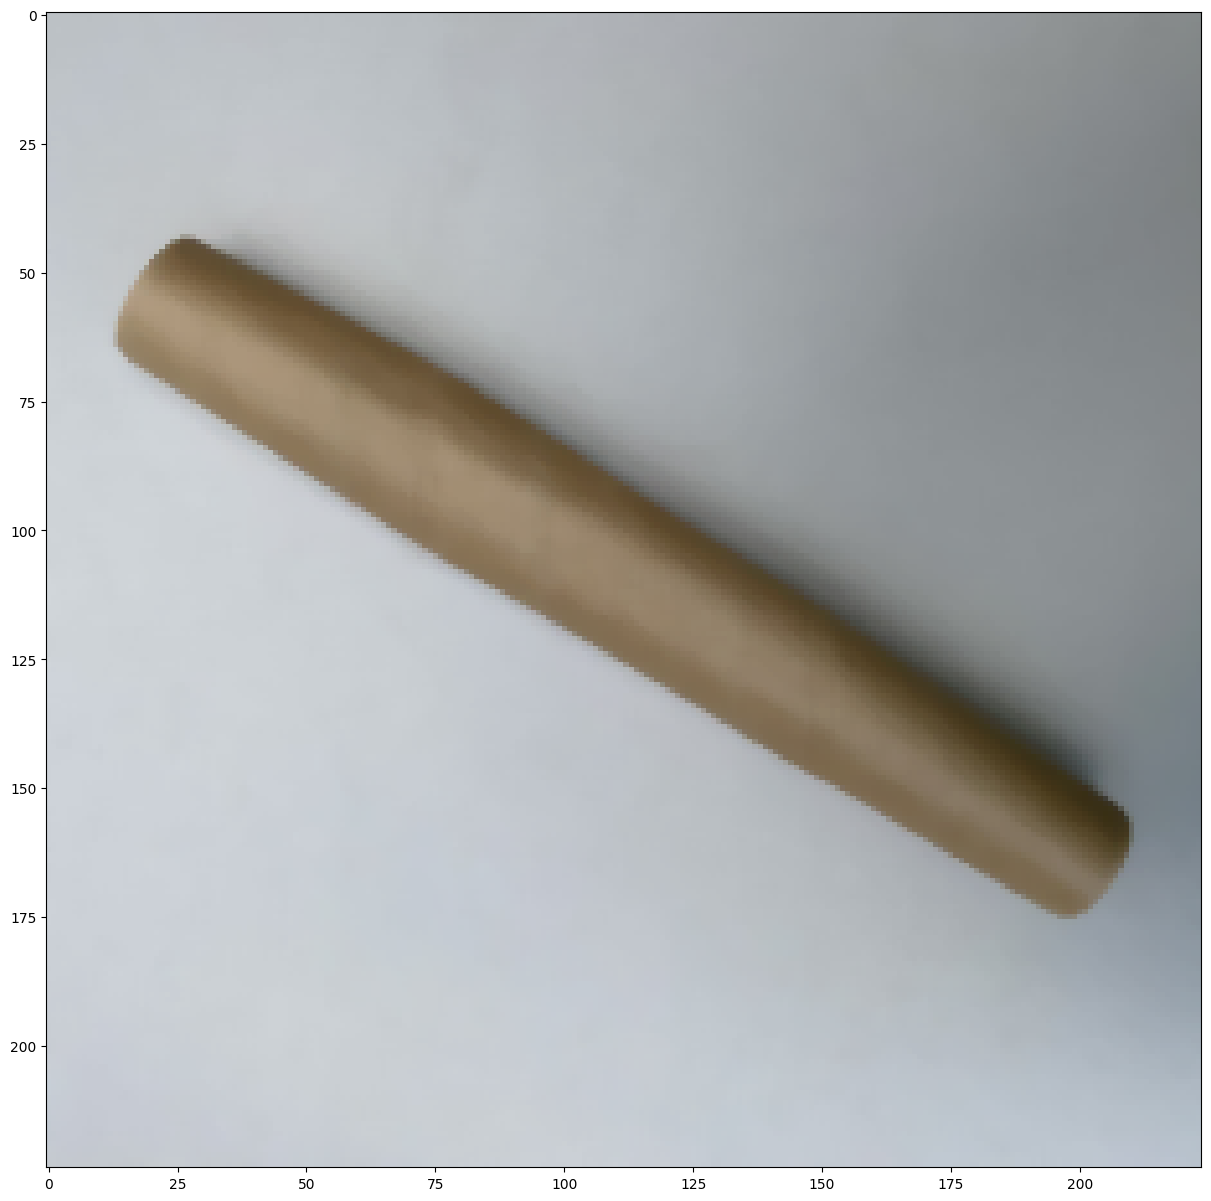

In [107]:
#median blur
plt.figure(figsize=(15,15))
plt.imshow(median_blur[0])

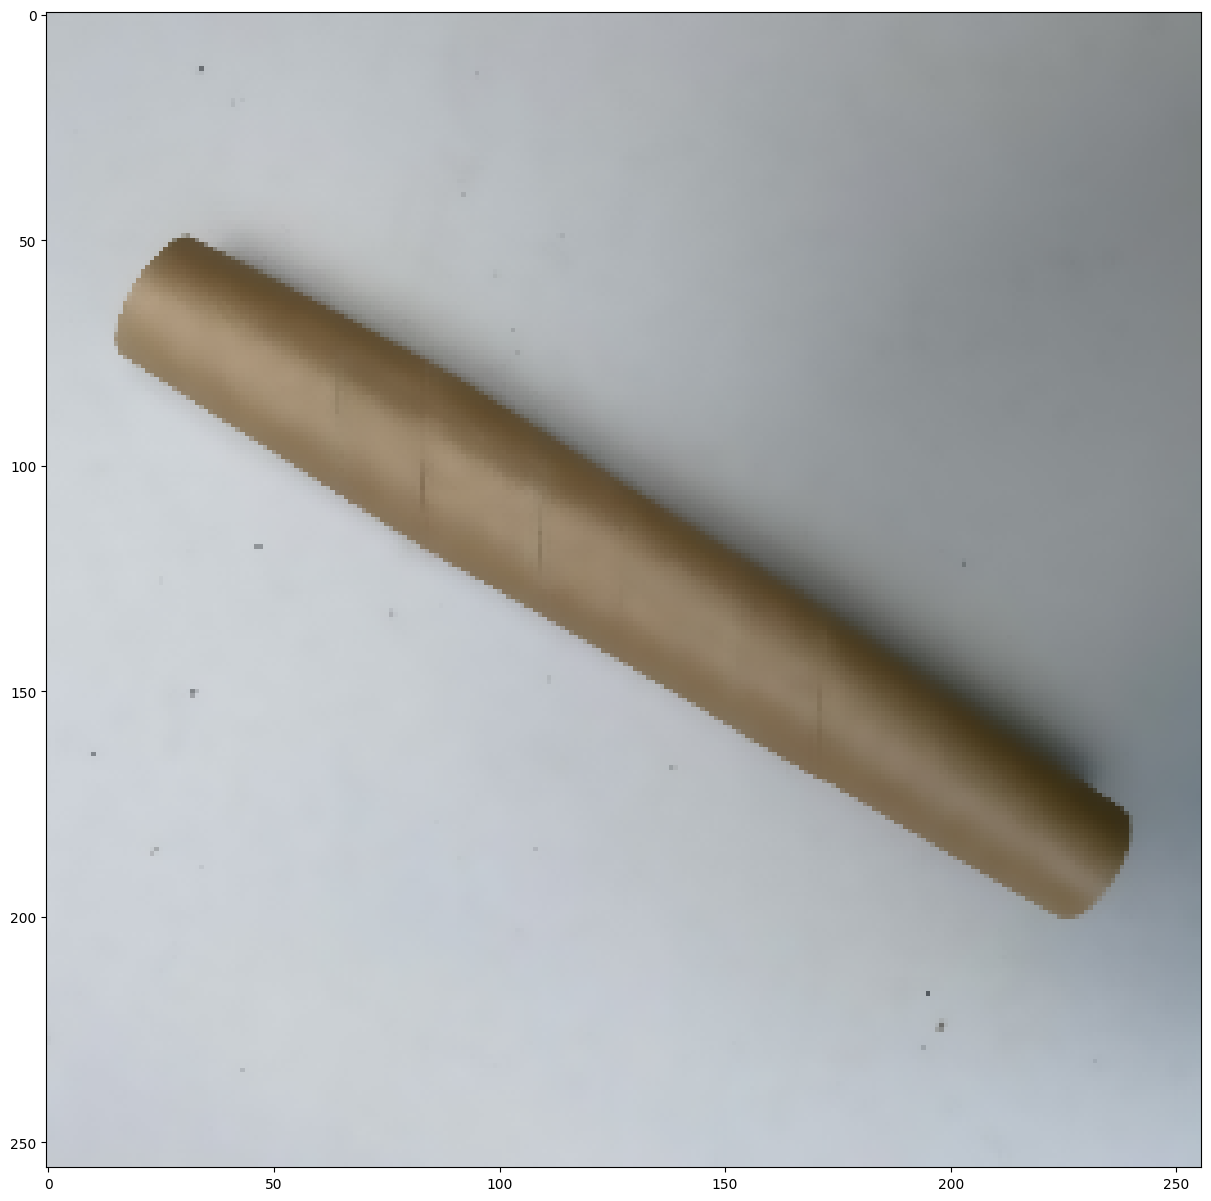

In [41]:
#Bilateral filter
plt.figure(figsize=(15,15))
plt.imshow(bilateral_filter[0])

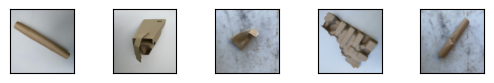

In [12]:

for i in range(5):
    plt.subplot(5,5,i+1)
    plt.imshow(bilateral_filter[i])
    plt.xticks([])
    plt.yticks([])
       
plt.show()

Applying the CLAHE (contrast enhancement technique)

In [42]:
# creating the object of clahe
clahe = cv2.createCLAHE(clipLimit=2.0 , tileGridSize=(9,9))
clahe_image_list = []

for index , image in enumerate(bilateral_filter):
    #converting the image from rgb to lab 
    image_lab = cv2.cvtColor(image,cv2.COLOR_RGB2LAB)
    #splitting the image into 3 channels
    L_channel,A_channel,B_channel = cv2.split(image_lab)
    #applying the clahe technique to only L_channel(light)
    clahe_L_channel = clahe.apply(L_channel)
    #Merging al 3 channels together
    clahe_image = cv2.merge((clahe_L_channel,A_channel,B_channel))
    #converting the image from lab to rgb
    clahe_image_rgb = cv2.cvtColor(clahe_image,cv2.COLOR_LAB2RGB)
    #Appending all enhanced images into single list 
    clahe_image_list.append(clahe_image_rgb)


In [ ]:
clahe_image_list[0]

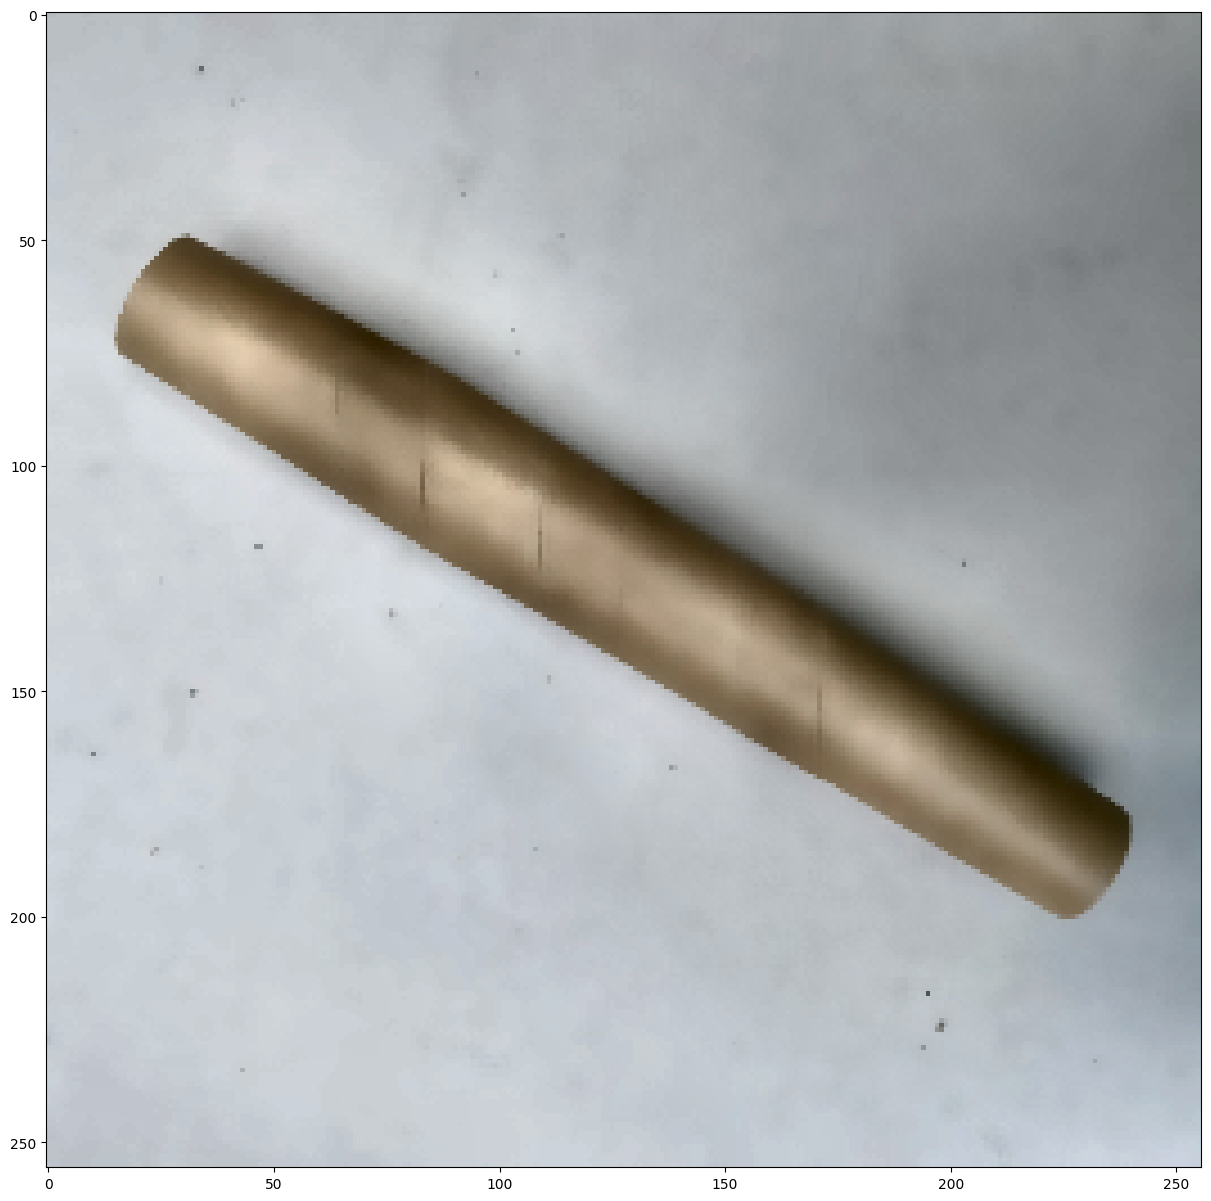

In [43]:
#viual image After clahe
plt.figure(figsize=(15,15))

plt.imshow(clahe_image_list[0])

plt.show()

Sharpening edge by Unmasking and normalizing

In [50]:
strenght = 1.5
normalized_image_listt = []
for index , image in enumerate(clahe_image_list):
    blurred_image = cv2.GaussianBlur(image, (0, 0), sigmaX=1.0, sigmaY=1.0)
    image_float = image.astype(np.float32)
    blurred_image_float = blurred_image.astype(np.float32)

    detail_layer =image_float - blurred_image_float

    sharped_image = image_float + detail_layer*strenght
    # 
    normalized_image = sharped_image.astype(np.float32)/255.0
    normalized_image = np.clip(normalized_image,0.0,1.0)

    normalized_image_listt.append(normalized_image)

converting into numpy array

In [44]:
X_dataset = np.array(clahe_image_list)
Y_dataset = np.array(all_image_label)
X_dataset[0]


array([[[182, 187, 192],
        [182, 187, 192],
        [185, 191, 195],
        ...,
        [139, 145, 145],
        [136, 142, 142],
        [139, 145, 145]],

       [[185, 191, 195],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [139, 145, 145],
        [138, 141, 142],
        [136, 142, 142]],

       [[185, 191, 195],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [139, 145, 145],
        [138, 141, 142],
        [138, 141, 142]],

       ...,

       [[190, 194, 201],
        [188, 195, 201],
        [190, 194, 201],
        ...,
        [200, 209, 221],
        [200, 209, 219],
        [200, 209, 219]],

       [[188, 195, 201],
        [188, 195, 201],
        [188, 195, 201],
        ...,
        [200, 209, 221],
        [200, 209, 221],
        [200, 209, 219]],

       [[192, 198, 205],
        [188, 195, 201],
        [188, 195, 201],
        ...,
        [200, 209, 221],
        [200, 209, 219],
        [200, 209, 219]]

In [45]:
X_dataset_final=[]
X_dataset_final = X_dataset.astype(np.float32)/255

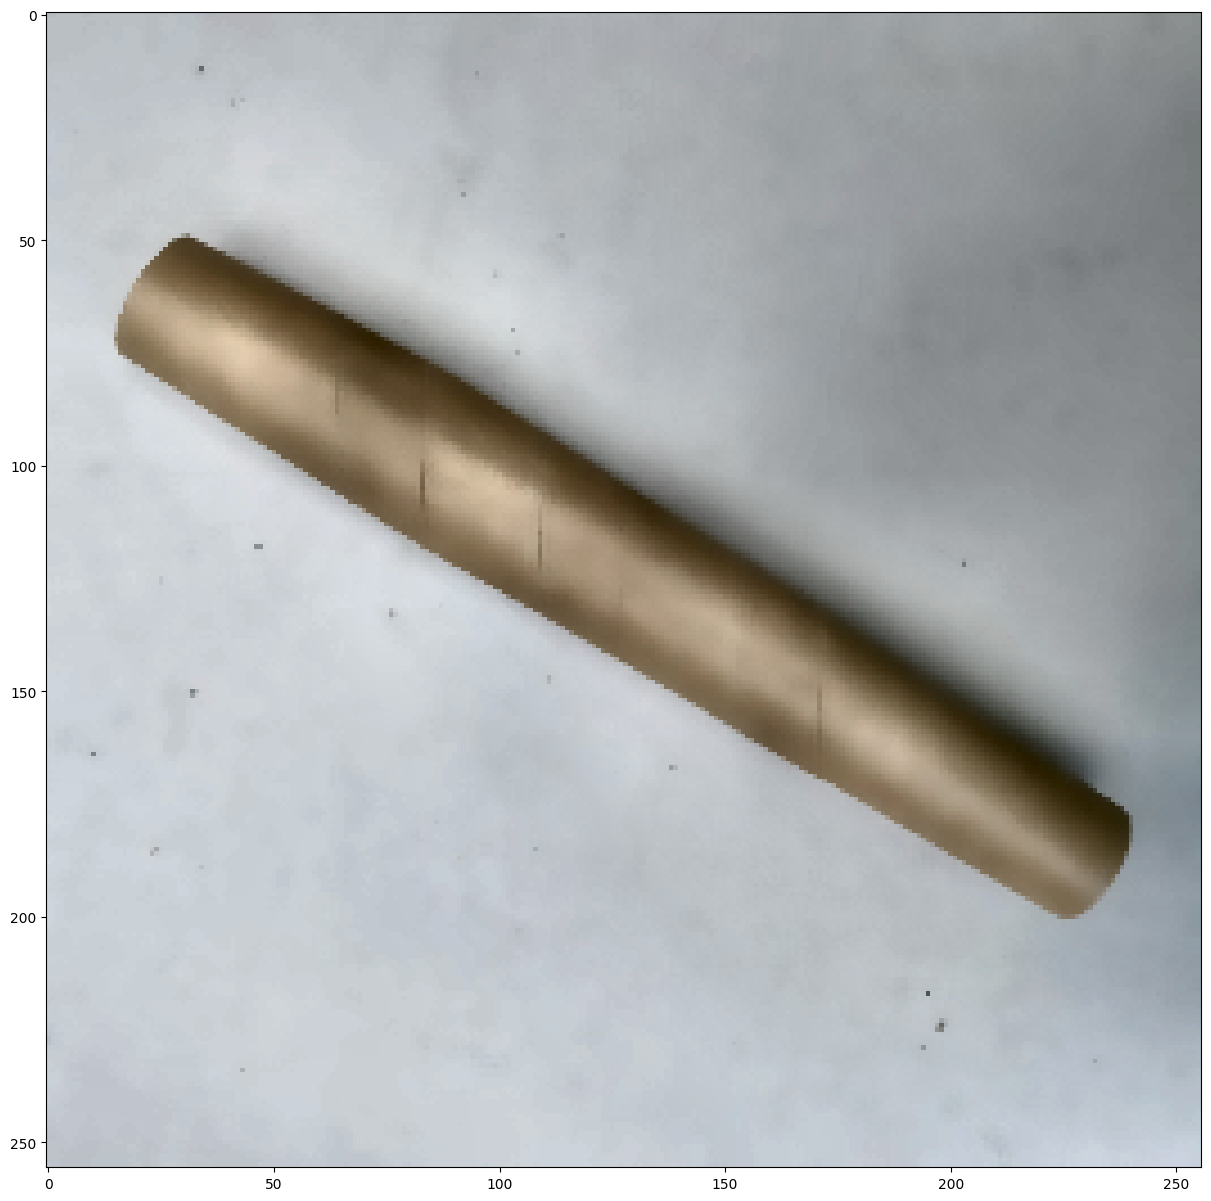

In [46]:
plt.figure(figsize=(15,15))
plt.imshow(X_dataset_final[0])

Splitting the data set

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_dataset,
    Y_dataset,
    test_size= 0.2,
    random_state=42, 
    stratify=Y_dataset  
)

In [48]:
print('Shape of X_train : ', X_train.shape)
print('Shape of X_test : ', X_test.shape)
print('Shape of Y_train : ', Y_train.shape)
print('Shape of Y_test : ', Y_test.shape)

Shape of X_train :  (3452, 256, 256, 3)
Shape of X_test :  (864, 256, 256, 3)
Shape of Y_train :  (3452,)
Shape of Y_test :  (864,)


In [57]:
model= tf.keras.Sequential([
    #Input Layer
    layers.Conv2D(filters = 10 ,kernel_size= (9,9) ,activation= 'relu' , input_shape =(256,256,3)),
    #HiddenLayer
    layers.Conv2D(filters = 10,kernel_size= (9,9) ,activation= 'relu' ),
    layers.Conv2D(filters = 10 ,kernel_size= (9,9) ,activation= 'relu' ),
    layers.MaxPool2D(),
    layers.Conv2D(filters = 10 ,kernel_size= (9,9) ,activation= 'relu' ),
    layers.Conv2D(filters = 10 ,kernel_size= (9,9) ,activation= 'relu' ),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(8,activation='softmax'),   
])

c:\Users\Inshal Munaf\VsCodeProjects\Waste_Classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
import tensorflow as tf
from tensorflow.keras import layers

NUM_CLASSES = 8 # Number of your waste categories
IMG_HEIGHT = 256 # Assuming your input image height
IMG_WIDTH = 256  # Assuming your input image width

model_light = tf.keras.Sequential([
    # Block 1
    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPool2D(pool_size=(2,2)),

    # Block 2
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPool2D(pool_size=(2,2)),

    # Block 3
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPool2D(pool_size=(2,2)),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'), 
    layers.Dropout(0.5), 

    layers.Dense(units=NUM_CLASSES, activation='softmax') # Output layer
])

model_light.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,472 (16.09 MB)

 Trainable params: 4,218,472 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

Model Compilation

In [58]:
model_light.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics =['accuracy']
)

Model Training

In [59]:
history = model_light.fit(
    X_train,
    Y_train,
    epochs=20,          
    batch_size=32,      
    validation_split=0.2                        
)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.1719 - loss: 4.1094 - val_accuracy: 0.1534 - val_loss: 2.0696
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.1899 - loss: 2.0668 - val_accuracy: 0.2301 - val_loss: 2.0602
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 290s 3s/step - accuracy: 0.1997 - loss: 2.0579 - val_accuracy: 0.2315 - val_loss: 2.0521
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.2066 - loss: 2.0462 - val_accuracy: 0.2315 - val_loss: 2.0460
Epoch 5/20
34/87 ━━━━━━━━━━━━━━━━━━━━ 2:55 3s/step - accuracy: 0.1954 - loss: 2.0453

KeyboardInterrupt: 